# Test : Harmonic Mean for Gefitinib Concentration Profile

In this section, we will compare the concentration profiles generated from the same layered tissue conditions as in exp02_heterogenous_tissue.ipynb, but instead comparing two methods for calculating the half-cell diffusitivity values; $D_{i+\frac{1}{2}}$ and $D_{i-\frac{1}{2}}$.

In [12]:
# Baseline Method : Arithmetic mean from exp02_heterogenous_tissue.ipynb.

import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Tissue depth range (cm)
L = 0.2             # 2 mm

# Number of spatial points
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Total simulation time (s)
T = 3600            # 1 hour

# Number of time steps
nt = 30000

dt = T / nt

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.12   # 1.2 mm

# Constant drug source at vessel boundary
C_source = 1.0

# Saving buffer
save_every = 25

# Solving heterogenous profile

C = np.zeros(nx)
C[0] = C_source

saved_profiles = []

# Time-stepping loop
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        # diffusitivies
        D_left = (D[i] + D[i-1]) / 2
        D_right = (D[i] + D[i+1]) / 2

        # diffusion fluxes
        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        # update concentration
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Re-apply source boundary condition
    C[0] = C_source

    if (t % save_every) == 0:
        saved_profiles.append(C.copy())

C_arithmetic = np.array(saved_profiles)

In [13]:
# Refined Method : Harmonic mean.

import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Tissue depth range (cm)
L = 0.2             # 2 mm

# Number of spatial points
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Total simulation time (s)
T = 3600            # 1 hour

# Number of time steps
nt = 30000

dt = T / nt

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.12   # 1.2 mm

# Diffusion coefficients for each layer (cm^2/s)
D1 = 5e-7           # Outer tumor region
D2 = 1e-7           # Dense / diffusion-limited region
D3 = 5e-7           # Deeper tumor region

# Spatial diffusitivity profile
D = np.full(nx, D1)

D[x >= boundary_1] = D2
D[x >= boundary_2] = D3

# Constant drug source at vessel boundary
C_source = 1.0

# Saving buffer
save_every = 25

# Solving heterogenous profile

C = np.zeros(nx)
C[0] = C_source

saved_profiles = []

# Time-stepping loop
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        # diffusitivies
        D_left = (2 * D[i-1] * D[i]) / (D[i-1] + D[i])
        D_right = (2 * D[i] * D[i+1]) / (D[i] + D[i+1])

        # diffusion fluxes
        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        # update concentration
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Re-apply source boundary condition
    C[0] = C_source

    if (t % save_every) == 0:
        saved_profiles.append(C.copy())

C_harmonic = np.array(saved_profiles)

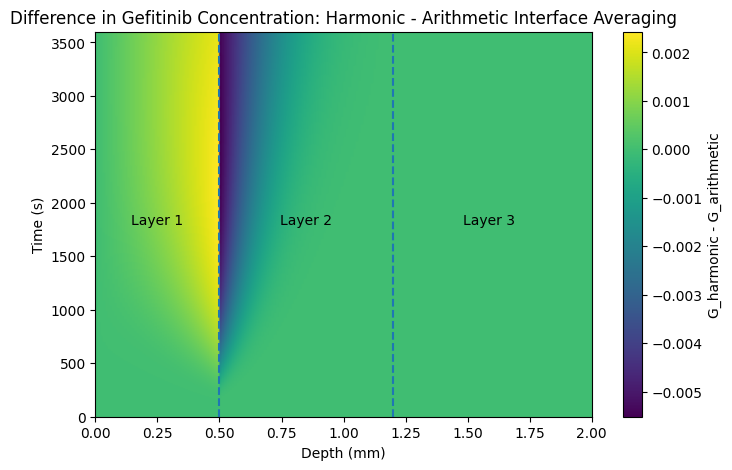

In [21]:
C_delta_heatmap = C_harmonic - C_arithmetic

plt.figure(figsize=(8, 5))

plt.imshow(

    C_delta_heatmap,

    aspect='auto',

    origin='lower',

    extent=[0, L * 10, 0, T]

)

plt.colorbar(label='G_harmonic - G_arithmetic')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Difference in Gefitinib Concentration: Harmonic - Arithmetic Interface Averaging')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp02_heterogeneous_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

plt.show()

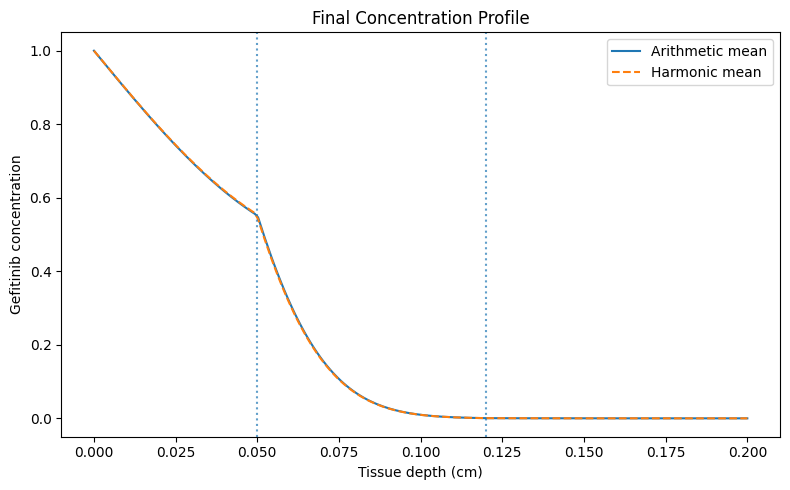

In [15]:
plt.figure(figsize=(8, 5))

C_arithmetic_final = C_arithmetic[-1]
C_harmonic_final = C_harmonic[-1]

plt.plot(x, C_arithmetic_final, label="Arithmetic mean")
plt.plot(x, C_harmonic_final, label="Harmonic mean", linestyle="--")

# Mark tissue interfaces
plt.axvline(boundary_1, linestyle=":", alpha=0.7)
plt.axvline(boundary_2, linestyle=":", alpha=0.7)

plt.xlabel("Tissue depth (cm)")
plt.ylabel("Gefitinib concentration")

plt.title("Final Concentration Profile")

plt.legend()
plt.tight_layout()
plt.show()

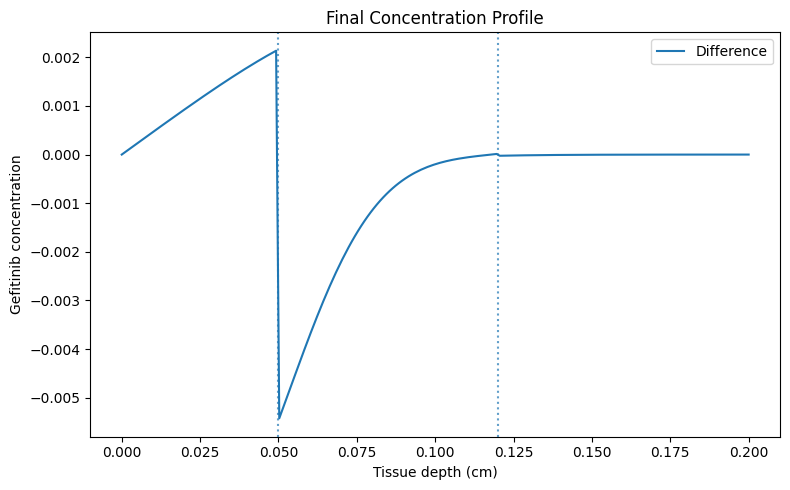

In [16]:
plt.figure(figsize=(8, 5))

C_difference = C_harmonic_final - C_arithmetic_final

plt.plot(x, C_difference, label="Difference")

# Mark tissue interfaces
plt.axvline(boundary_1, linestyle=":", alpha=0.7)
plt.axvline(boundary_2, linestyle=":", alpha=0.7)

plt.xlabel("Tissue depth (cm)")
plt.ylabel("Gefitinib concentration")

plt.title("Final Concentration Profile")

plt.legend()
plt.tight_layout()
plt.show()

In [17]:
difference = C_harmonic_final - C_arithmetic_final

max_abs_difference = np.max(np.abs(difference))

relative_difference = (
    max_abs_difference /
    np.max(C_arithmetic_final)
) * 100

rmse = np.sqrt(
    np.mean(difference**2)
)

print(f"Maximum absolute difference: {max_abs_difference:.6f}")
print(f"Maximum difference (% of source concentration): {relative_difference:.3f}%")
print(f"RMSE: {rmse:.6f}")

Maximum absolute difference: 0.005426
Maximum difference (% of source concentration): 0.543%
RMSE: 0.001456


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters

# Solver tolerances
rtol = 1e-9
atol = 1e-12

# Load validated exp04b outputs
T_steady = np.load("saved_parameters/exp04b_T_steady.npy")

# Initial state vector
y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Parameter dictionary
params_baseline = {
    "EGF" : 1.0,
    "IC_50" : 0.3,
    "n" : 1.0,
    "k_EGF" : 1.0,
    "k_EGFR_off" : 0.5,
    "k_G" : 0.5,
    "k_RAS" : 1.0,
    "k_RAS_off" : 0.5,
    "k_RAF" : 1.0,
    "k_RAF_off" : 0.5,
    "k_MEK" : 1.0,
    "k_MEK_off" : 0.5,
    "k_ERK" : 1.0,
    "k_ERK_off" : 0.5,
    "k_T" : 1.0,
    "k_deg" : 0.5,
    "k_P" : 1.0,
    "k_loss" : 0.5,
}

# ODE Signaling Function
def pathway(t, y, params, G_x):
    # External factors
    EGF = params["EGF"]
    G = G_x
    IC_50 = params["IC_50"]
    n = params["n"]

    # Extract activated protein and Cyclin D/Proliferation rates from array y
    EGFR_star, RAS_star, RAF_star, MEK_star, ERK_star, CycD, P = y

    # Total protein concentrations
    EGFR_tot = 1.0
    RAS_tot = 1.0
    RAF_tot = 1.0
    MEK_tot = 1.0
    ERK_tot = 1.0

    # Rate constants (normalized currently)
    k_EGF = params["k_EGF"]
    k_EGFR_off = params["k_EGFR_off"]
    k_G = params["k_G"]

    k_RAS = params["k_RAS"]
    k_RAS_off = params["k_RAS_off"]

    k_RAF = params["k_RAF"]
    k_RAF_off = params["k_RAF_off"]

    k_MEK = params["k_MEK"]
    k_MEK_off = params["k_MEK_off"]

    k_ERK = params["k_ERK"]
    k_ERK_off = params["k_ERK_off"]

    k_T = params["k_T"]
    k_deg = params["k_deg"]

    k_P = params["k_P"]
    k_loss = params["k_loss"]

    # Calculating derivatives
    EGFR_gefit = 1 / (1 + (G / IC_50) ** n)
    EGFR_act = k_EGF * EGF * (EGFR_tot - EGFR_star) * EGFR_gefit
    EGFR_dect = k_EGFR_off * EGFR_star

    dEGFR = EGFR_act - EGFR_dect

    RAS_act = k_RAS * EGFR_star * (RAS_tot - RAS_star)
    RAS_dect = k_RAS_off * RAS_star

    dRAS = RAS_act - RAS_dect

    RAF_act = k_RAF * RAS_star * (RAF_tot - RAF_star)
    RAF_dect = k_RAF_off * RAF_star

    dRAF = RAF_act - RAF_dect

    MEK_act = k_MEK * RAF_star * (MEK_tot - MEK_star)
    MEK_dect = k_MEK_off * MEK_star

    dMEK = MEK_act - MEK_dect

    ERK_act = k_ERK * MEK_star * (ERK_tot - ERK_star)
    ERK_dect = k_ERK_off * ERK_star

    dERK = ERK_act - ERK_dect

    CycD_act = k_T * ERK_star
    CycD_dect = k_deg * CycD

    dCycD = CycD_act - CycD_dect

    P_act = k_P * CycD
    P_dect = k_loss * P

    dP = P_act - P_dect

    return [dEGFR, dRAS, dRAF, 
                dMEK, dERK, dCycD, dP]

# Central ODE simulation function
def run_spatial_model(params, G_profile):
    solutions = np.zeros((7, len(x)))

    for i in range(len(x)):
        G_local = G_profile[i]

        sol = solve_ivp(
            pathway,
            [0, T_steady],
            y0,
            args=(params, G_local),
            rtol=rtol,
            atol=atol
        )

        solutions[:, i] = sol.y[:, -1]

    return solutions


In [20]:
# CV calcuation function, modified for specifically G(x, t) at t = T, or G(x).
def calculate_CV(G):

    params = params_baseline.copy()

    solutions = run_spatial_model(
        params,
        G
    )

    P = solutions[6]

    return np.std(P) / np.mean(P), P

CV_harmonic, P_harmonic = calculate_CV(G=C_harmonic_final)
CV_arithmetic, P_arithmetic = calculate_CV(G=C_arithmetic_final)

In [24]:
P_difference = P_harmonic - P_arithmetic
max_P_difference = np.max(np.abs(P_difference))

print(f"Max Difference = {max_P_difference}")

percent_change_CV = (CV_harmonic - CV_arithmetic) / CV_arithmetic

print(f"CV_P% = {percent_change_CV * 100}%")

Max Difference = 0.0005511142614806896
CV_P% = 0.08686952549184833%
